# Anggota Kelompok :
# Hauzan Rafi Atallah (103052330011)
# Taufik Qurohman (103052300055)

#1. Cleaning Data


##1.1 Import Library & Baca Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


df = pd.read_csv('/content/gym_members_exercise_tracking.csv')

Kami mengimpor library utama dan memuat data gym ke dalam dataframe.

##1.2 Cek Dimensi, Tipe Data, dan Sample Data



In [4]:
dimensi = df.shape
tipe_data = df.dtypes
sample_data = df.head()
(dimensi, tipe_data, sample_data)

((973, 15),
 Age                                int64
 Gender                            object
 Weight (kg)                      float64
 Height (m)                       float64
 Max_BPM                            int64
 Avg_BPM                            int64
 Resting_BPM                        int64
 Session_Duration (hours)         float64
 Calories_Burned                  float64
 Workout_Type                      object
 Fat_Percentage                   float64
 Water_Intake (liters)            float64
 Workout_Frequency (days/week)      int64
 Experience_Level                   int64
 BMI                              float64
 dtype: object,
    Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
 0   56    Male         88.3        1.71      180      157           60   
 1   46  Female         74.9        1.53      179      151           66   
 2   32  Female         68.1        1.66      167      122           54   
 3   25    Male         53.2        1.70  

Kami memeriksa jumlah baris, kolom, tipe data setiap kolom, dan contoh data untuk memahami struktur data gym.

##1.3 Cek Nilai Unik Kolom Kategorikal

In [5]:
unique_gender = df['Gender'].unique()
unique_workout_type = df['Workout_Type'].unique()
unique_experience_level = df['Experience_Level'].unique()
(unique_gender, unique_workout_type, unique_experience_level)

(array(['Male', 'Female'], dtype=object),
 array(['Yoga', 'HIIT', 'Cardio', 'Strength'], dtype=object),
 array([3, 2, 1]))

Kami melihat variasi data pada kolom Gender, Workout_Type, dan Experience_Level untuk mengetahui keragaman data non-numerik.

##1.4 Cek dan Tangani Missing Value

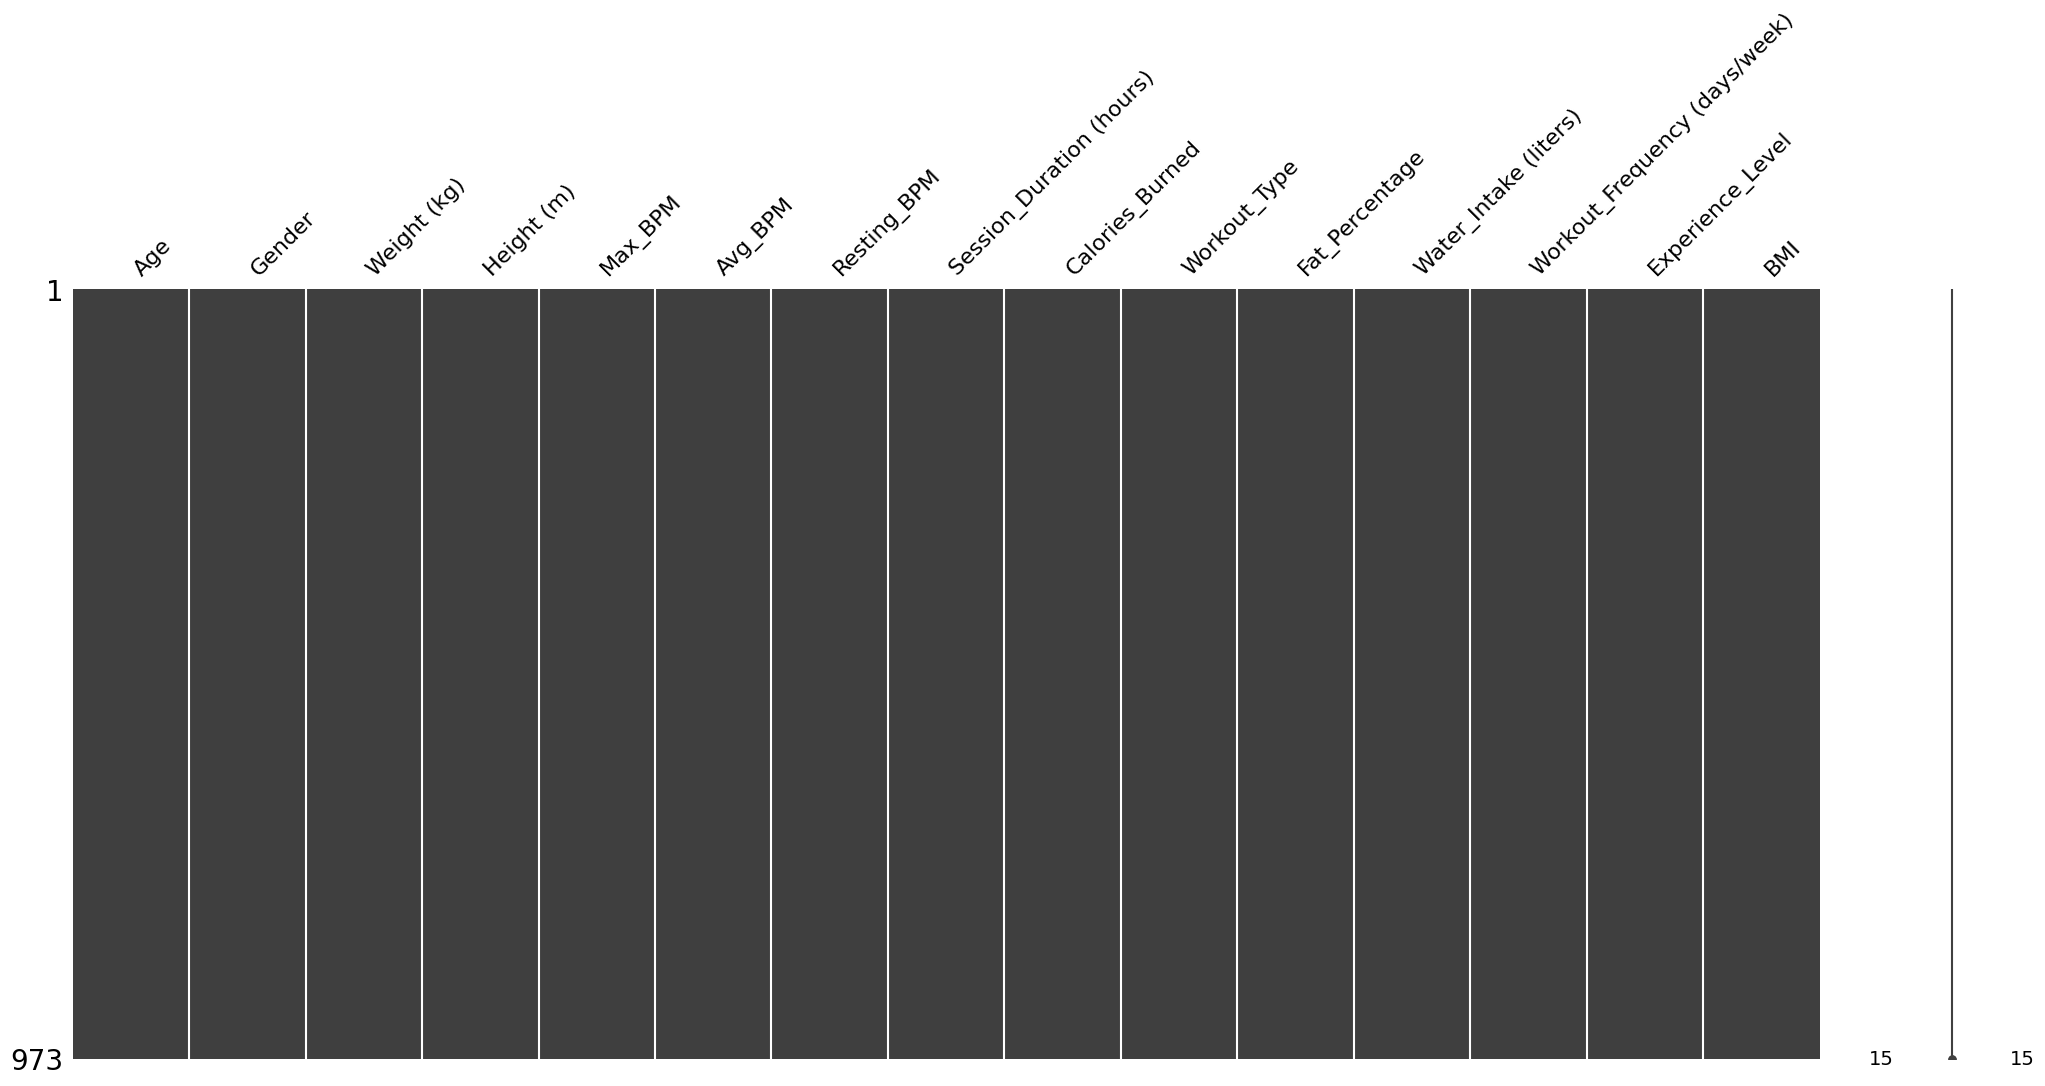

In [6]:
missing_values = df.isnull().sum()
msno.matrix(df)
plt.show()
df = df.dropna()

Kami menghitung jumlah data kosong di setiap kolom, memvisualisasikannya, dan menghapus baris dengan missing value agar analisis lebih akurat.

##1.5 Cek dan Hapus Data Duplikat

In [7]:
jumlah_duplikat = df.duplicated().sum()
df = df.drop_duplicates()
jumlah_duplikat_baru = df.duplicated().sum()
print("Jumlah duplikat sebelum penghapusan:", jumlah_duplikat)
print("Jumlah duplikat setelah penghapusan:", jumlah_duplikat_baru)

Jumlah duplikat sebelum penghapusan: 0
Jumlah duplikat setelah penghapusan: 0


Baris data yang duplikat dihitung dan dihapus untuk memastikan keunikan data tiap member gym.

## 1.6 Deteksi dan Penanganan Outlier

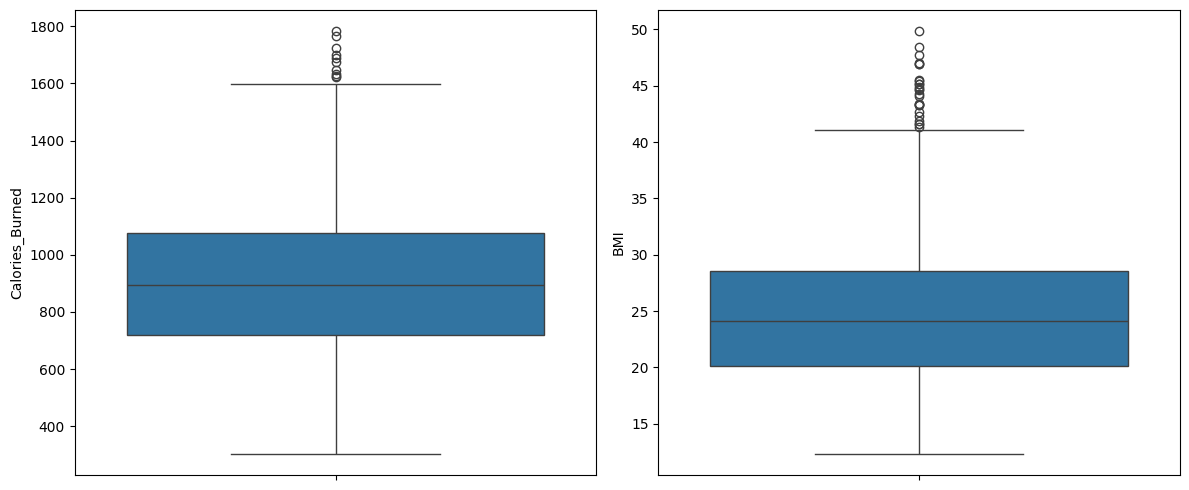

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(y=df['Calories_Burned'], ax=axs[0])
sns.boxplot(y=df['BMI'], ax=axs[1])
plt.tight_layout()
plt.show()

## 1.7 Reset Index

In [9]:
df = df.reset_index(drop=True)

Setelah proses cleaning, index direset agar data tetap rapi dan urut.

#2. EDA

##2.1 Statistik Deskriptif

In [10]:
statistik_deskriptif = df.describe(include='all')
statistik_deskriptif

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973,973.000000,973.000000,973.000000,973.000000,973.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Strength,NaN,NaN,NaN,NaN,NaN
freq,NaN,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,258,NaN,NaN,NaN,NaN,NaN
mean,38.683453,NaN,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,NaN,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,NaN,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,NaN,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,NaN,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,NaN,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,NaN,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,NaN,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,NaN,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,NaN,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,NaN,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,NaN,29.300000,3.100000,4.000000,2.000000,28.560000


Statistik deskriptif digunakan untuk melihat karakteristik data gym baik numerik maupun kategorikal.

##2.2 Analisis Data Kategorikal

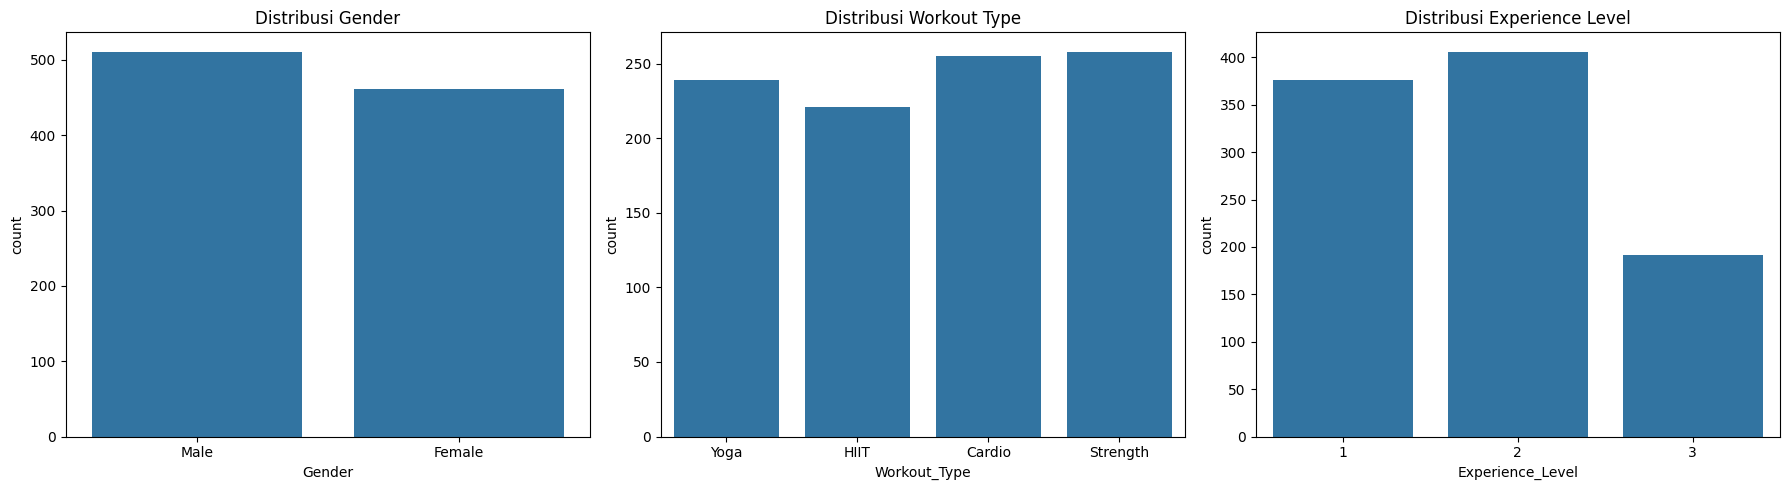

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(18,5))
sns.countplot(x='Gender', data=df, ax=axs[0])
axs[0].set_title('Distribusi Gender')
sns.countplot(x='Workout_Type', data=df, ax=axs[1])
axs[1].set_title('Distribusi Workout Type')
sns.countplot(x='Experience_Level', data=df, ax=axs[2])
axs[2].set_title('Distribusi Experience Level')
plt.tight_layout()
plt.show()


Kami menghitung sebaran Gender, Workout_Type, dan Experience_Level agar tahu distribusi tiap kategori.

##2.3 Analisis Korelasi Numerik

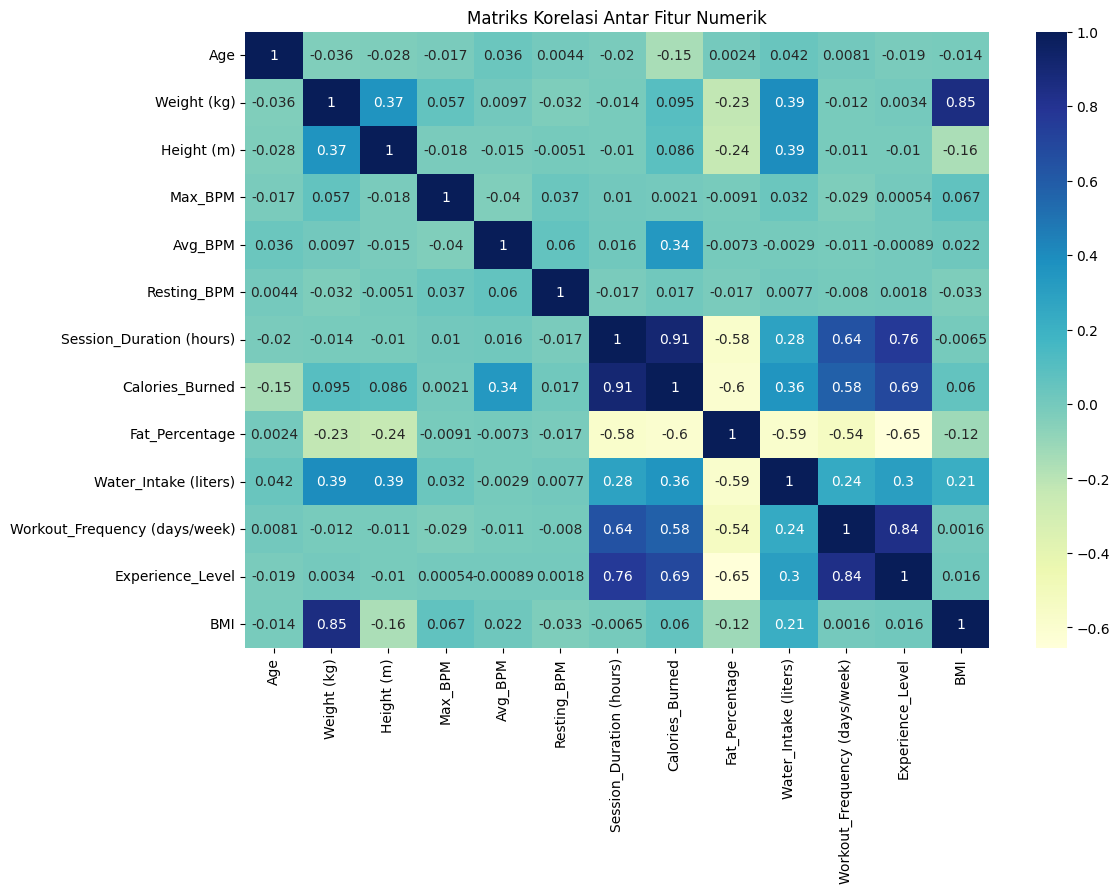

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.title('Matriks Korelasi Antar Fitur Numerik')
plt.show()

Berdasarkan heatmap korelasi, terdapat hubungan sangat kuat antara Calories_Burned dengan Session_Duration (0.91), serta antara BMI dengan Weight (0.85), dan antara Workout_Frequency dengan Experience_Level (0.84). Korelasi positif ini menandakan semakin lama durasi latihan atau semakin sering berlatih, kalori yang terbakar pun meningkat, dan semakin berat badan seseorang, BMI-nya juga cenderung lebih tinggi. Sebaliknya, Fat_Percentage memiliki korelasi negatif dengan Workout_Frequency dan Experience_Level, yang berarti semakin sering dan berpengalaman seseorang berolahraga, persentase lemak tubuhnya cenderung lebih rendah.

##2.4 Analisis Outlier Setelah Cleaning

In [13]:
def hitung_outlier(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    bawah = q1 - 1.5*iqr
    atas = q3 + 1.5*iqr
    return ((series < bawah) | (series > atas)).sum()

outlier_calories = hitung_outlier(df['Calories_Burned'])
outlier_bmi = hitung_outlier(df['BMI'])
(outlier_calories, outlier_bmi)

(np.int64(10), np.int64(25))

#3. Visualisasi **Data**

##3.1 Distribusi Usia dan BMI Member Gym

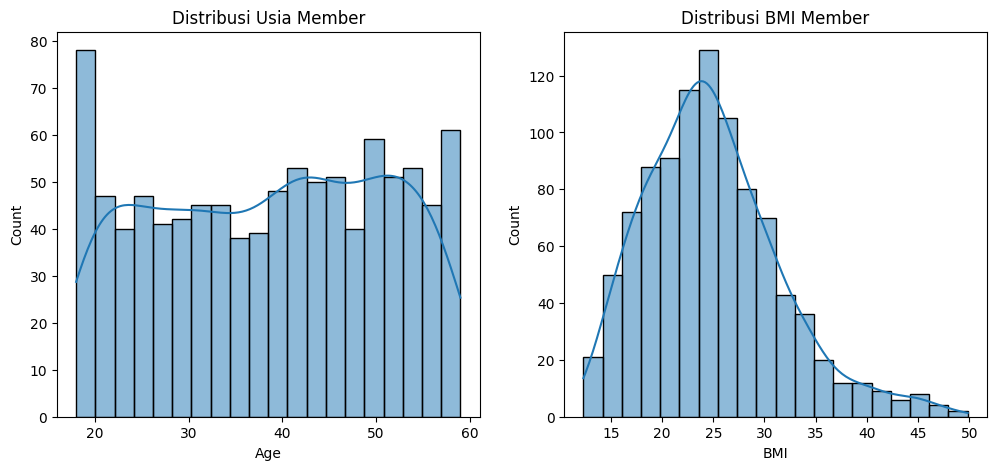

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Age'], bins=20, kde=True, ax=axs[0])
axs[0].set_title('Distribusi Usia Member')
sns.histplot(df['BMI'], bins=20, kde=True, ax=axs[1])
axs[1].set_title('Distribusi BMI Member')
plt.show()


Visualisasi di atas menunjukkan dua distribusi penting dari data member gym. Grafik sebelah kiri memperlihatkan distribusi usia yang cukup merata dari usia 20 hingga 60 tahun, dengan jumlah terbanyak berada di kelompok usia 18–20 tahun, lalu relatif stabil di usia dewasa. Sementara itu, grafik kanan menunjukkan distribusi BMI yang membentuk kurva menyerupai distribusi normal condong ke kanan (right-skewed), dengan sebagian besar anggota memiliki BMI antara 20 hingga 27, menandakan bahwa mayoritas berada dalam rentang berat badan normal hingga sedikit overweight.

##3.2 Distribusi Workout Type dan Gender

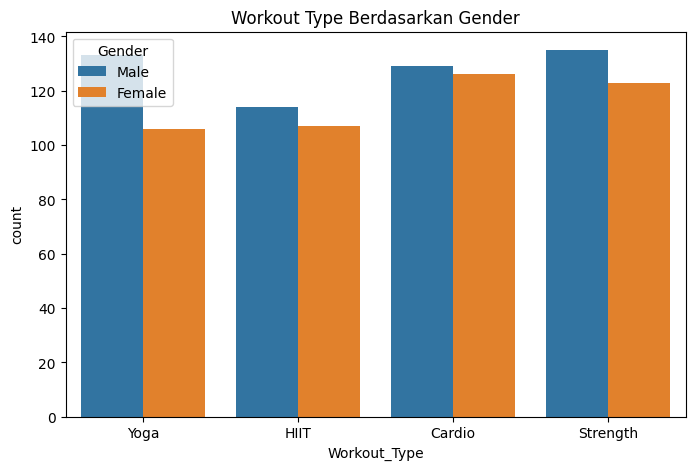

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Workout_Type', data=df, hue='Gender')
plt.title('Workout Type Berdasarkan Gender')
plt.show()

Distribusi workout type menunjukkan bahwa jumlah peserta laki-laki dan perempuan cukup seimbang di setiap jenis latihan, dengan laki-laki sedikit lebih dominan pada Strength dan Yoga, sementara Cardio dan HIIT diminati secara merata oleh kedua gender.

## 3.3 Boxplot BMI Berdasarkan Gender

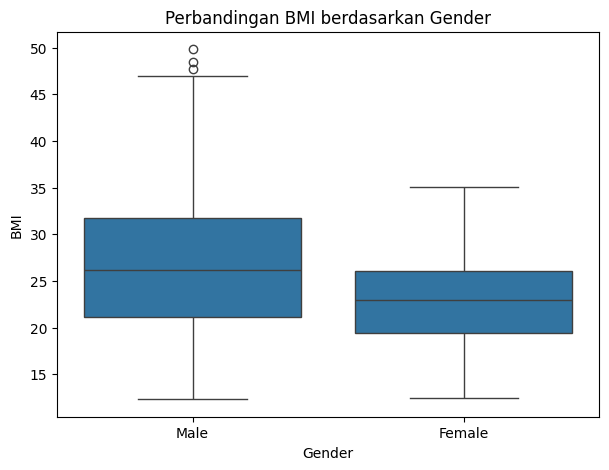

In [16]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Gender', y='BMI', data=df)
plt.title('Perbandingan BMI berdasarkan Gender')
plt.show()


Boxplot menunjukkan bahwa median BMI laki-laki sedikit lebih tinggi dibanding perempuan, dengan sebaran BMI laki-laki juga lebih lebar serta terdapat beberapa outlier BMI tinggi pada kelompok laki-laki. Namun, kedua gender memiliki rentang BMI yang cukup mirip di kisaran 20–30.

## 3.4 Calories Burned Berdasarkan Workout Type

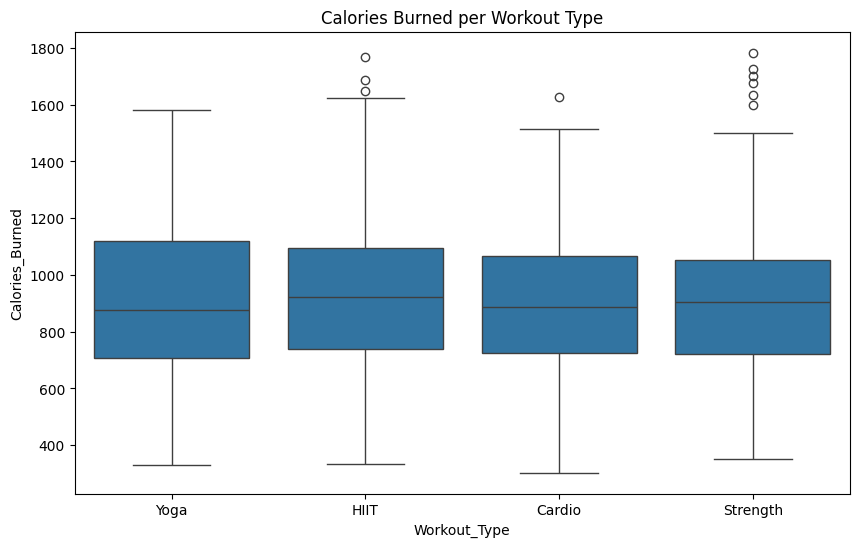

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Workout_Type', y='Calories_Burned', data=df)
plt.title('Calories Burned per Workout Type')
plt.show()

Boxplot menunjukkan bahwa rata-rata kalori terbakar untuk semua jenis latihan (Yoga, HIIT, Cardio, Strength) relatif mirip, namun HIIT dan Strength memiliki lebih banyak outlier di atas 1.600 kalori, menandakan beberapa peserta membakar kalori dalam jumlah yang sangat tinggi pada jenis latihan tersebut.

##3.5 Relationship Fat Percentage vs BMI

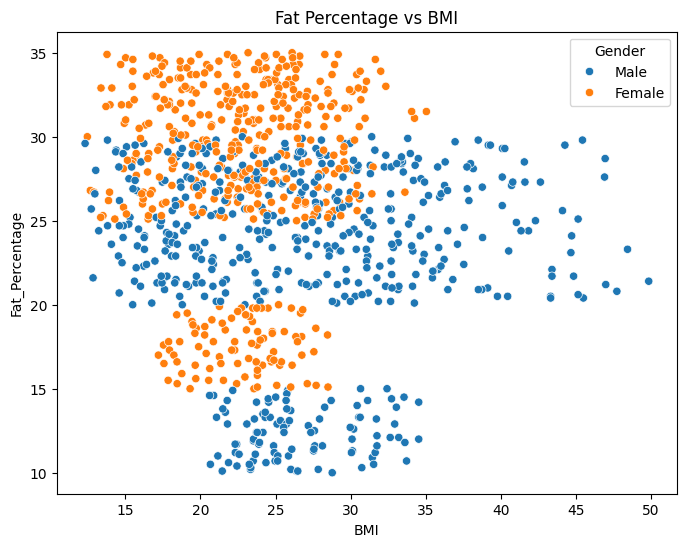

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='BMI', y='Fat_Percentage', hue='Gender', data=df)
plt.title('Fat Percentage vs BMI')
plt.show()


Scatterplot memperlihatkan bahwa terdapat kecenderungan positif antara BMI dan fat percentage, terutama pada perempuan yang umumnya memiliki fat percentage lebih tinggi di setiap level BMI. Selain itu, pada BxMI yang sama, variasi fat percentage laki-laki lebih besar dan cenderung memiliki nilai yang lebih rendah dibanding perempuan.

##3.6 Rata-rata Calories Burned per Level Pengalaman



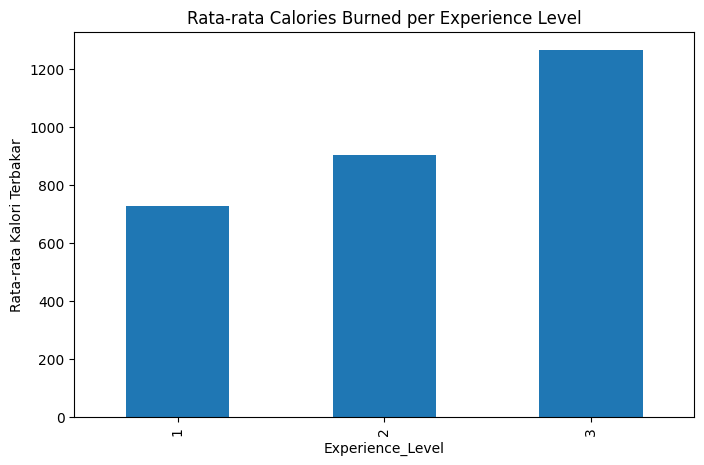

In [19]:
level_calories = df.groupby('Experience_Level')['Calories_Burned'].mean()
plt.figure(figsize=(8,5))
level_calories.plot(kind='bar')
plt.title('Rata-rata Calories Burned per Experience Level')
plt.ylabel('Rata-rata Kalori Terbakar')
plt.show()


Grafik menunjukkan bahwa semakin tinggi level pengalaman member gym, semakin besar pula rata-rata kalori yang terbakar per sesi latihan, menandakan member yang lebih berpengalaman cenderung melakukan latihan yang lebih berat atau intensif.

##3.7 Komposisi Gender

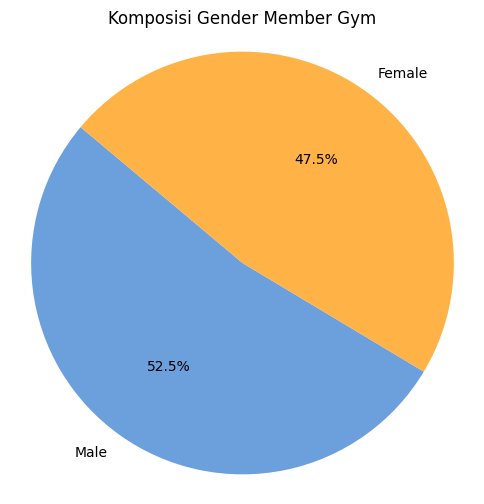

In [20]:
plt.figure(figsize=(6,6))
gender_counts = df['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=['#6ca0dc','#ffb347'])
plt.title('Komposisi Gender Member Gym')
plt.axis('equal')
plt.show()


Berdasarkan pie chart, komposisi gender member gym cukup seimbang, dengan sedikit lebih banyak laki-laki (52,5%) dibandingkan perempuan (47,5%). Hal ini menunjukkan gym ini menarik minat kedua gender hampir sama besar.

In [23]:
!mkdir /content/project
!cp *.ipynb /content/project/

cp: cannot stat '*.ipynb': No such file or directory


In [22]:
!ls /content/project

ls: cannot access '/content/project': No such file or directory
